# Bloque IV — Clustering (Entrega Sobresaliente)

Segmentación avanzada con K-Means, evaluación completa y acciones de negocio.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline

In [2]:
df = pd.read_csv("segmentacion_clientes_mayo_2026.csv")
df.head()

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones,cliente_id
0,32713.930757,2.798984,57.118050,15.883976,74.290733,0,S2000
1,79117.581351,26.884645,152.289208,67.328111,7.115590,2,S2001
2,67501.684036,20.623894,185.243439,92.128428,4.397256,4,S2002
3,42542.107281,6.134401,53.107646,31.597353,22.766703,2,S2003
4,26341.424546,4.283298,34.558218,6.006453,76.764440,0,S2004


## Selección de variables

In [3]:
features = [
    "ingresos",
    "compras_12m",
    "ticket_medio",
    "visitas_web",
    "dias_desde_ultima_compra",
    "reclamaciones"
]

X = df[features]

## Escalado

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Método del codo + Silhouette

In [5]:
k_values = range(2, 8)
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouettes
})

results

,k,inertia,silhouette
0,2,1183.538632,0.482286
1,3,691.844384,0.475763
2,4,564.421060,0.458921
3,5,488.067185,0.412354
4,6,419.643088,0.353315
5,7,395.045420,0.341498


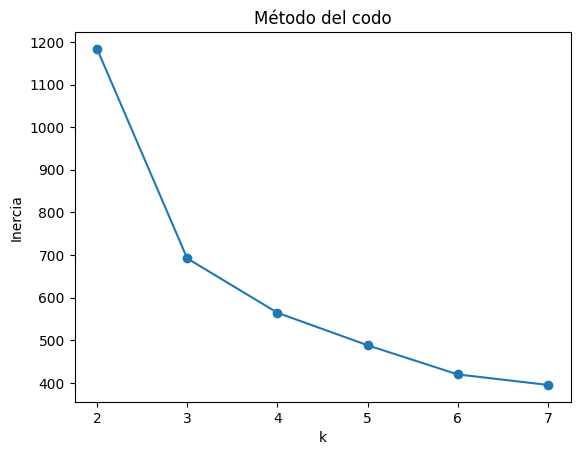

In [6]:
plt.figure()
plt.plot(results["k"], results["inertia"], marker="o")
plt.title("Método del codo")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.show()

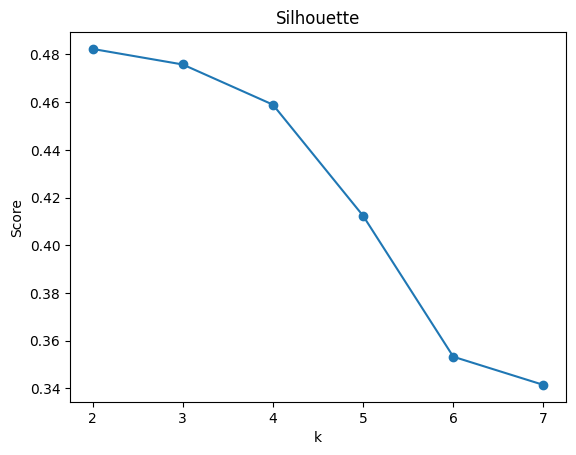

In [7]:
plt.figure()
plt.plot(results["k"], results["silhouette"], marker="o")
plt.title("Silhouette")
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

## Selección de k

In [8]:
best_k = int(results.sort_values("silhouette", ascending=False).iloc[0]["k"])
best_k

2

In [9]:
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X_scaled)

## PCA visualización

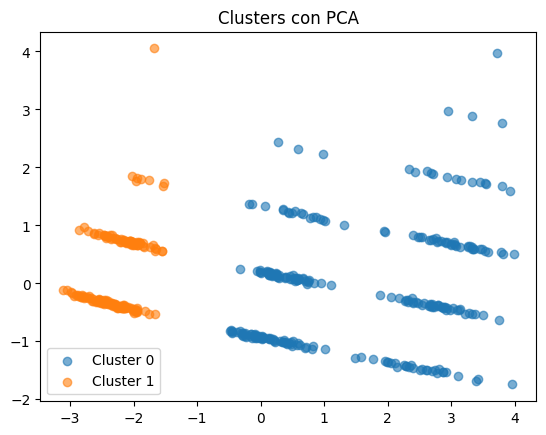

In [10]:
pca = PCA(n_components=2)
comp = pca.fit_transform(X_scaled)

df["PC1"] = comp[:,0]
df["PC2"] = comp[:,1]

plt.figure()
for c in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.6)

plt.legend()
plt.title("Clusters con PCA")
plt.show()

## Perfilado de clusters

In [11]:
perfil = df.groupby("cluster")[features].mean().round(2)
perfil

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones
cluster,,,,,,
0,54003.76,15.03,135.30,62.25,16.70,1.01
1,24220.90,3.02,40.34,12.55,80.39,0.46


## Naming de clusters

In [12]:
nombres = {}

for i, row in perfil.iterrows():
    if row["ticket_medio"] > perfil["ticket_medio"].mean():
        nombres[i] = "Clientes VIP"
    elif row["visitas_web"] > perfil["visitas_web"].mean():
        nombres[i] = "Alta interacción"
    elif row["dias_desde_ultima_compra"] > perfil["dias_desde_ultima_compra"].mean():
        nombres[i] = "En riesgo"
    else:
        nombres[i] = "Clientes estándar"

nombres

{0: 'Clientes VIP', 1: 'En riesgo'}

## Conclusiones y acciones


- Los clusters permiten identificar segmentos claros de clientes.
- Clientes VIP → fidelización premium.
- Alta interacción → campañas de conversión.
- En riesgo → reactivación urgente.
- Estándar → mantenimiento.

El uso combinado de silhouette y PCA garantiza una segmentación consistente y útil para negocio.
